#Library Imports

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

# 1️⃣ Download Data

In [ ]:
tickers = ["TSCO.L", "NXT.L"]
prices_raw = yf.download(tickers, start="2024-11-01", end="2025-11-12")
prices = prices_raw['Close'].copy()

/tmp/ipython-input-1246685529.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices_raw = yf.download(tickers, start="2024-11-01", end="2025-11-12")
[*********************100%***********************]  2 of 2 completed


# Drop NaNs (data cleaning)

In [ ]:
# Initial cleaning
# Drop rows where all tickers are NaN
prices = prices.dropna(how='all')

# Forward-fill and backward-fill remaining NaNs (in case some tickers have missing values)
prices = prices.fillna(method='ffill').fillna(method='bfill')

# Reset index to get a clean sequential DataFrame
prices = prices.reset_index(drop=False)  # keep date column

# 3️ preview cleaned data
print(prices.head())

Ticker       Date         NXT.L      TSCO.L
0      2024-11-01   9911.971680  347.873352
1      2024-11-04   9879.979492  351.671967
2      2024-11-05  10037.946289  353.771179
3      2024-11-06   9899.974609  357.169922
4      2024-11-07   9919.970703  348.373138


/tmp/ipython-input-429032527.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  prices = prices.fillna(method='ffill').fillna(method='bfill')


# 3 Feature Engineering

In [ ]:
df = prices.copy()
for ticker in tickers:
    close_col = ticker

    # --- Lagged prices ---
    for lag in [1,5,10]:
        df[f"{ticker}_Lag{lag}"] = df[close_col].shift(lag)

    # --- Multi-horizon returns ---
    for horizon in [1,5,21,63]:
        df[f"{ticker}_Ret{horizon}"] = df[close_col].pct_change(horizon)

    # --- Moving averages & EMAs ---
    for window in [5,10,20,50]:
        df[f"{ticker}_SMA{window}"] = df[close_col].rolling(window).mean()
    df[f"{ticker}_EMA12"] = df[close_col].ewm(span=12, adjust=False).mean()
    df[f"{ticker}_EMA26"] = df[close_col].ewm(span=26, adjust=False).mean()
    df[f"{ticker}_EMA50"] = df[close_col].ewm(span=50, adjust=False).mean()

    # --- MACD ---
    df[f"{ticker}_MACD"] = df[f"{ticker}_EMA12"] - df[f"{ticker}_EMA26"]
    df[f"{ticker}_MACD_signal"] = df[f"{ticker}_MACD"].ewm(span=9, adjust=False).mean()
    df[f"{ticker}_MACD_hist"] = df[f"{ticker}_MACD"] - df[f"{ticker}_MACD_signal"]

    # --- RSI ---
    delta = df[close_col].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    roll_up = gain.rolling(14, min_periods=5).mean()
    roll_down = loss.rolling(14, min_periods=5).mean()
    rs = np.where(roll_down == 0, 0, roll_up / roll_down)
    df[f"{ticker}_RSI14"] = 100 - (100 / (1 + rs))

    # --- Rolling volatility & skew/kurtosis ---
    df[f"{ticker}_Volatility20"] = df[f"{ticker}_Ret1"].rolling(20).std()
    df[f"{ticker}_Skew20"] = df[f"{ticker}_Ret1"].rolling(20).skew()
    df[f"{ticker}_Kurt20"] = df[f"{ticker}_Ret1"].rolling(20).kurt()

    # --- Stochastic Oscillator ---
    low14 = df[close_col].rolling(14, min_periods=5).min()
    high14 = df[close_col].rolling(14, min_periods=5).max()
    rng14 = high14 - low14
    df[f"{ticker}_StochK14"] = np.where(rng14==0, 50, 100 * (df[close_col] - low14) / rng14)
    df[f"{ticker}_StochD3"] = df[f"{ticker}_StochK14"].rolling(3, min_periods=2).mean()


In [ ]:
#df = df.dropna().reset_index(drop=True)

# Store the processed df before target creation for later use in backtesting.
#df_base_for_splitting = df.copy()

# 3️⃣ Targets & Features

In [ ]:
# X_dict, y_dict = {}, {}
# df_processed_for_target_dict = {}

# for ticker in tickers:
#     df_temp = df_base_for_splitting.copy()
#     df_temp[f"Target_{ticker}"] = df_temp[ticker].shift(-1)
#     df_temp = df_temp.dropna().reset_index(drop=True)
#     df_processed_for_target_dict[ticker] = df_temp.copy()

#     features = [col for col in df_temp.columns if col.startswith(f"{ticker}_") and not col.startswith(f"Target_{ticker}")]
#     X_dict[ticker] = df_temp[features].values
#     y_dict[ticker] = df_temp[f"Target_{ticker}"].values

In [ ]:
# df_base_for_splitting = df.copy()

# from sklearn.preprocessing import StandardScaler

# X_dict = {}
# y_dict = {}
# X_scaled_dict = {}
# df_processed_for_target_dict = {}
# scaler_dict = {}

# for ticker in tickers:

#     df_temp = df_base_for_splitting.copy()
#     df_temp[f"Target_{ticker}"] = df_temp[ticker].shift(-1)
#     df_temp = df_temp.dropna().reset_index(drop=True)
#     df_processed_for_target_dict[ticker] = df_temp.copy()

#     features = [
#         col for col in df_temp.columns
#         if col.startswith(f"{ticker}_") and not col.startswith(f"Target_{ticker}")
#     ]

#     X = df_temp[features].values
#     y = df_temp[f"Target_{ticker}"].values

#     X_dict[ticker] = X
#     y_dict[ticker] = y

#     scaler = StandardScaler()
#     X_scaled = scaler.fit_transform(X)

#     X_scaled_dict[ticker] = X_scaled
#     scaler_dict[ticker] = scaler

# 4️⃣ Train/Test Split

In [ ]:
split_ratio = 0.8
X_train_dict, X_test_dict = {}, {}
y_train_dict, y_test_dict = {}, {}
split_idx_dict = {}

for ticker in tickers:
    split_idx = int(len(X_dict[ticker]) * split_ratio)
    X_train_dict[ticker], X_test_dict[ticker] = X_dict[ticker][:split_idx], X_dict[ticker][split_idx:]
    y_train_dict[ticker], y_test_dict[ticker] = y_dict[ticker][:split_idx], y_dict[ticker][split_idx:]
    split_idx_dict[ticker] = split_idx

In [ ]:
df_base_for_splitting = df.copy()

from sklearn.preprocessing import StandardScaler

X_dict = {}
y_dict = {}
X_scaled_dict = {}
df_processed_for_target_dict = {}
scaler_dict = {}

for ticker in tickers:

    df_temp = df_base_for_splitting.copy()
    df_temp[f"Target_{ticker}"] = df_temp[ticker].shift(-1)
    df_temp = df_temp.dropna().reset_index(drop=True)
    df_processed_for_target_dict[ticker] = df_temp.copy()

    features = [
        col for col in df_temp.columns
        if col.startswith(f"{ticker}_") and not col.startswith(f"Target_{ticker}")
    ]

    X = df_temp[features].values
    y = df_temp[f"Target_{ticker}"].values

    X_dict[ticker] = X
    y_dict[ticker] = y

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    X_scaled_dict[ticker] = X_scaled
    scaler_dict[ticker] = scaler

# 5️⃣ Models & Hyperparameters

In [ ]:
models = {
    "Random Forest": RandomForestRegressor(random_state=42),
    "Ridge Regression": Ridge(),
    "XGBoost": XGBRegressor(objective='reg:squarederror', random_state=42)
}

param_grids = {
    "Random Forest": {'feature_selector__k':[5,'all'],'model__n_estimators':[100,200],'model__max_depth':[None,10]},
    "Ridge Regression": {'feature_selector__k':[5,'all'],'model__alpha':[0.1,1,10]},
    "XGBoost": {'feature_selector__k':[5,'all'],'model__n_estimators':[100,200],'model__max_depth':[3,5],'model__learning_rate':[0.01,0.1]}
}

predictions_dict = {ticker:{} for ticker in tickers}
best_model_dict = {ticker:{} for ticker in tickers}

# 6️⃣ Training, Prediction & Evaluation


===== TSCO.L =====

--- Random Forest ---
Best Params: {'model__n_estimators': 100, 'model__max_depth': None, 'feature_selector__k': 5}
MSE: 298.834393
RMSE: 17.286827
MAE: 13.872493
R²: -1.1938
Directional Acc: 0.5897


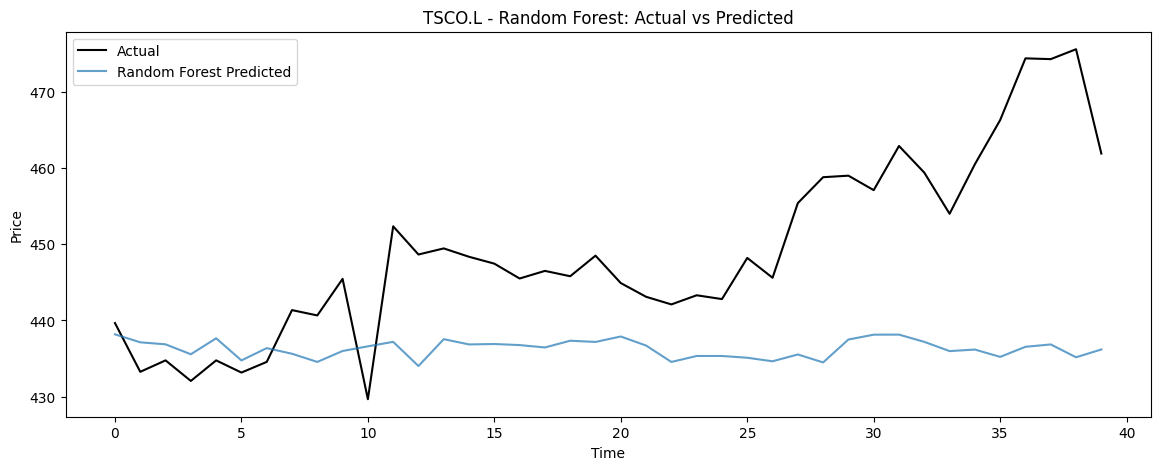


--- Ridge Regression ---
Best Params: {'model__alpha': 1, 'feature_selector__k': 'all'}
MSE: 62.559213
RMSE: 7.909438
MAE: 5.942512
R²: 0.5407
Directional Acc: 0.3333


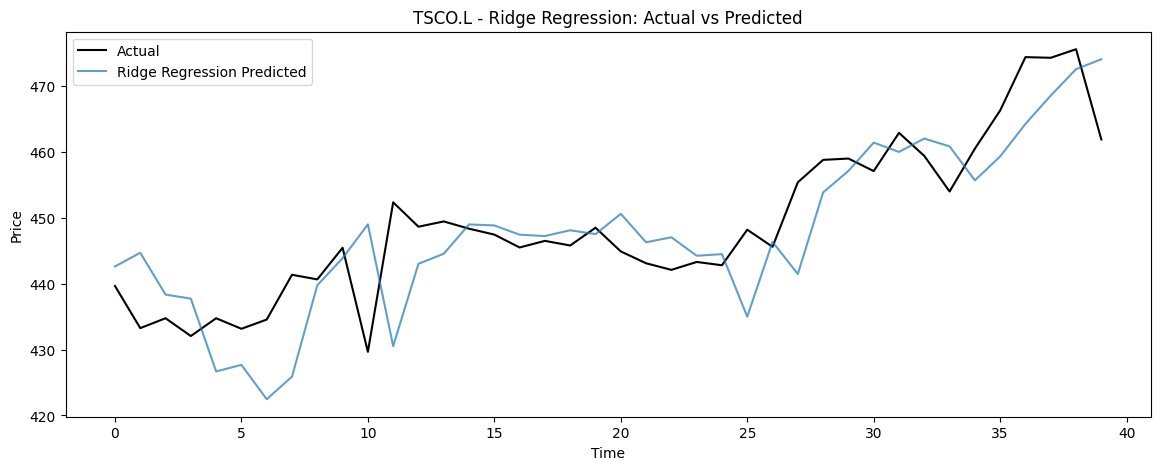


--- XGBoost ---
Best Params: {'model__n_estimators': 100, 'model__max_depth': 3, 'model__learning_rate': 0.1, 'feature_selector__k': 5}
MSE: 458.167790
RMSE: 21.404854
MAE: 18.080209
R²: -2.3635
Directional Acc: 0.5385


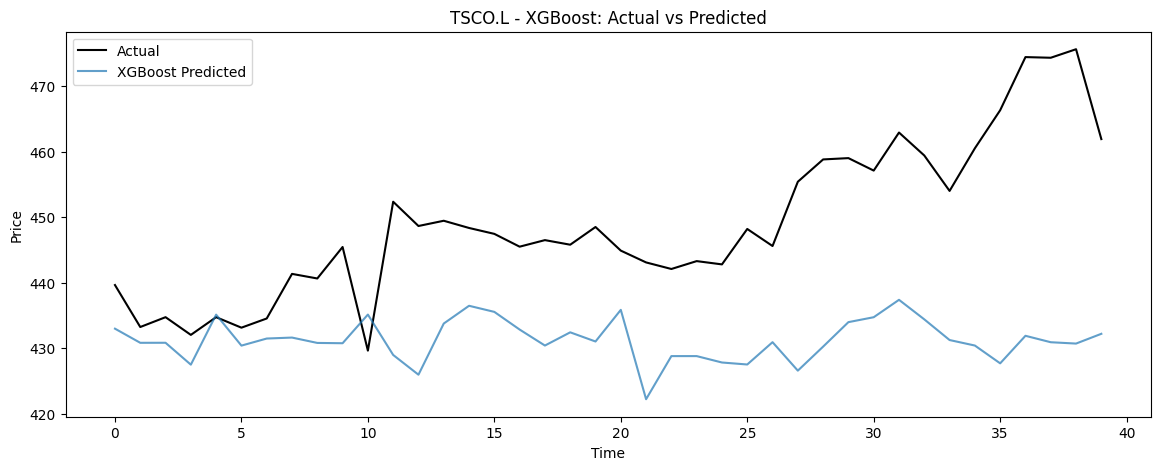


===== NXT.L =====

--- Random Forest ---
Best Params: {'model__n_estimators': 100, 'model__max_depth': None, 'feature_selector__k': 'all'}
MSE: 765459.789980
RMSE: 874.905589
MAE: 667.810632
R²: 0.0777
Directional Acc: 0.3077


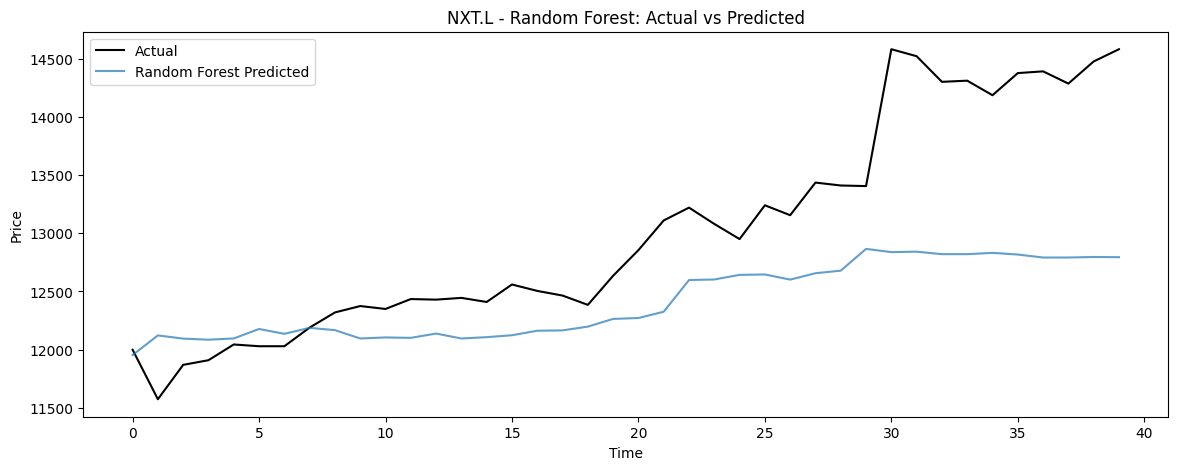


--- Ridge Regression ---
Best Params: {'model__alpha': 10, 'feature_selector__k': 'all'}
MSE: 103096.808466
RMSE: 321.086917
MAE: 213.361857
R²: 0.8758
Directional Acc: 0.4615


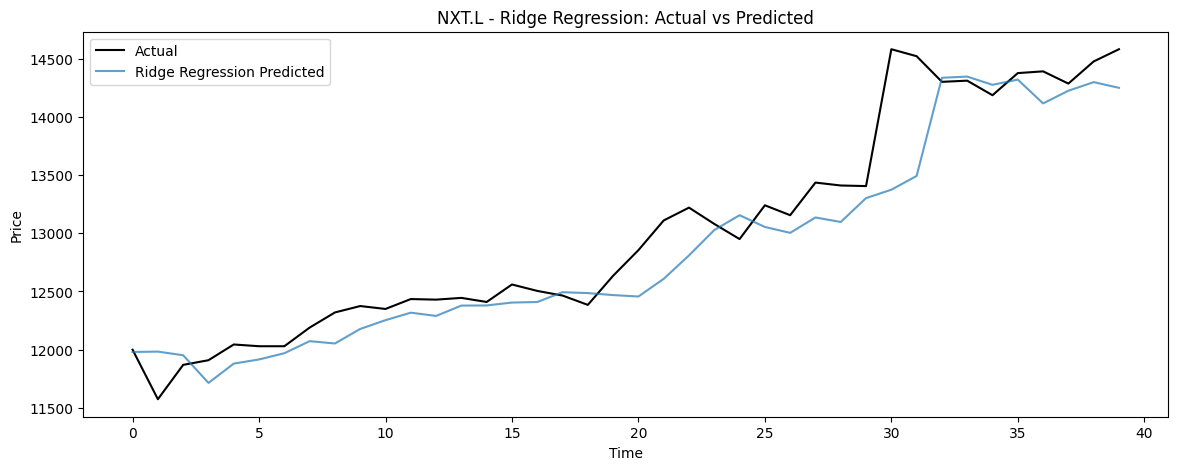


--- XGBoost ---
Best Params: {'model__n_estimators': 200, 'model__max_depth': 3, 'model__learning_rate': 0.1, 'feature_selector__k': 'all'}
MSE: 832976.045299
RMSE: 912.675213
MAE: 666.815820
R²: -0.0037
Directional Acc: 0.5641


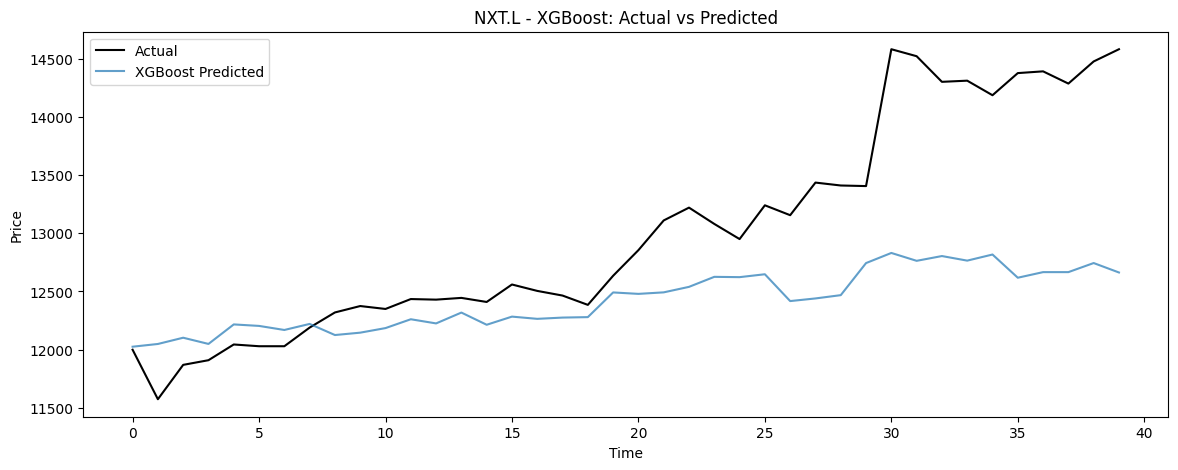

In [ ]:
for ticker in tickers:
    print(f"\n===== {ticker} =====")
    X_train, X_test = X_train_dict[ticker], X_test_dict[ticker]
    y_train, y_test = y_train_dict[ticker], y_test_dict[ticker]

    for model_name, model in models.items():
        print(f"\n--- {model_name} ---")
        max_components = min(X_train.shape[1], 5)

        pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('feature_selector', SelectKBest(f_regression)),
            ('pca', PCA(n_components=max_components)),
            ('model', model)
        ])

        grid_search = RandomizedSearchCV(
            pipeline, param_distributions=param_grids[model_name],
            cv=TimeSeriesSplit(n_splits=3), scoring='neg_mean_squared_error',
            n_iter=2, n_jobs=-1, verbose=0
        )
        grid_search.fit(X_train, y_train)
        best_model = grid_search.best_estimator_
        best_model_dict[ticker][model_name] = best_model
        print("Best Params:", grid_search.best_params_)

        preds = best_model.predict(X_test)
        predictions_dict[ticker][model_name] = preds

        mse = mean_squared_error(y_test, preds)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test, preds)
        r2 = r2_score(y_test, preds)
        directional_acc = np.mean(np.sign(preds[1:]-preds[:-1])==np.sign(y_test[1:]-y_test[:-1]))
        print(f"MSE: {mse:.6f}\nRMSE: {rmse:.6f}\nMAE: {mae:.6f}\nR²: {r2:.4f}\nDirectional Acc: {directional_acc:.4f}")

        # Plot actual vs predicted
        plt.figure(figsize=(14,5))
        plt.plot(y_test, label="Actual", color="black")
        plt.plot(preds, label=f"{model_name} Predicted", alpha=0.7)
        plt.title(f"{ticker} - {model_name}: Actual vs Predicted")
        plt.xlabel("Time")
        plt.ylabel("Price")
        plt.legend()
        plt.show()


# 7️⃣ Backtesting Function

In [ ]:
def backtest_strategy(current_prices, y_test, preds, ticker_name, model_name):
    current_prices = np.asarray(current_prices).reshape(-1)
    y_test = np.asarray(y_test).reshape(-1)
    preds = np.nan_to_num(np.asarray(preds).reshape(-1), nan=0.0, posinf=0.0, neginf=0.0)

    realized_returns = (y_test / current_prices) - 1
    signals = np.where(preds > current_prices, 1, np.where(preds < current_prices, -1, 0))
    strategy_returns = signals * realized_returns
    valid_returns = strategy_returns[~np.isnan(strategy_returns)]

    if len(valid_returns) == 0 or np.std(valid_returns)==0:
        print(f"\n[{ticker_name}] {model_name} Strategy: Not enough variation")
        return

    equity = np.cumprod(1 + strategy_returns)
    final_equity = equity[-1]
    sharpe = (np.mean(valid_returns)/np.std(valid_returns))*np.sqrt(252)
    drawdown = (equity - np.maximum.accumulate(equity)) / np.maximum.accumulate(equity)
    mdd = np.min(drawdown)

    print(f"\n[{ticker_name}] {model_name} Strategy Performance:")
    print(f"Final Equity Value : {final_equity:.3f}")
    print(f"Sharpe Ratio       : {sharpe:.2f}")
    print(f"Max Drawdown       : {mdd:.2%}")

    plt.figure(figsize=(12,5))
    plt.plot(equity, color='blue', label='Equity Curve')
    plt.title(f'{ticker_name} - {model_name} Strategy Backtest')
    plt.xlabel('Time Steps')
    plt.ylabel('Equity (normalized)')
    plt.grid(True)
    plt.legend()
    plt.show()



 8️⃣ Run Backtesting


[TSCO.L] Random Forest Strategy Performance:
Final Equity Value : 1.095
Sharpe Ratio       : 2.77
Max Drawdown       : -7.21%


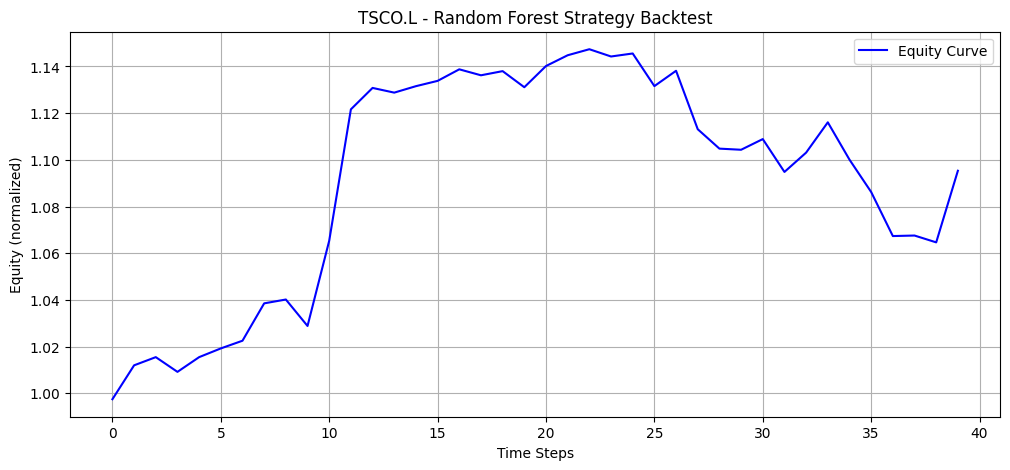


[TSCO.L] Ridge Regression Strategy Performance:
Final Equity Value : 0.974
Sharpe Ratio       : -0.65
Max Drawdown       : -6.18%


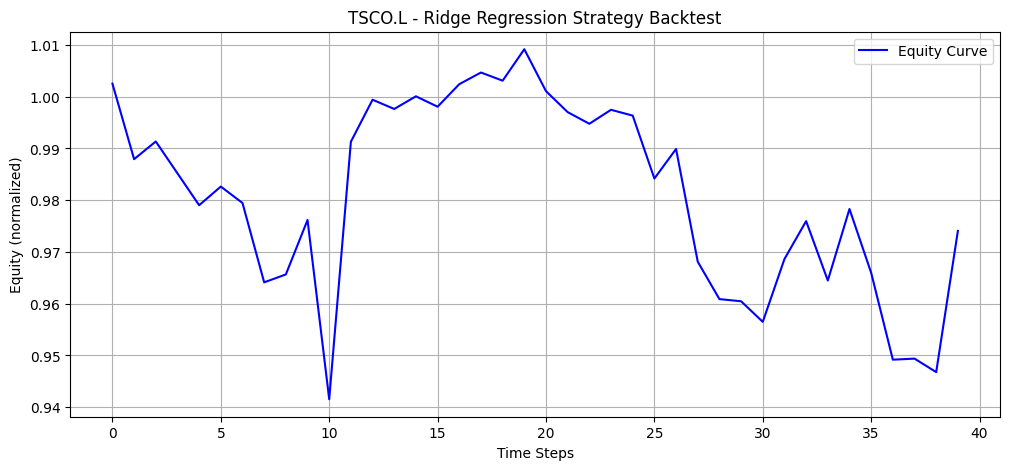


[TSCO.L] XGBoost Strategy Performance:
Final Equity Value : 0.954
Sharpe Ratio       : -1.25
Max Drawdown       : -10.09%


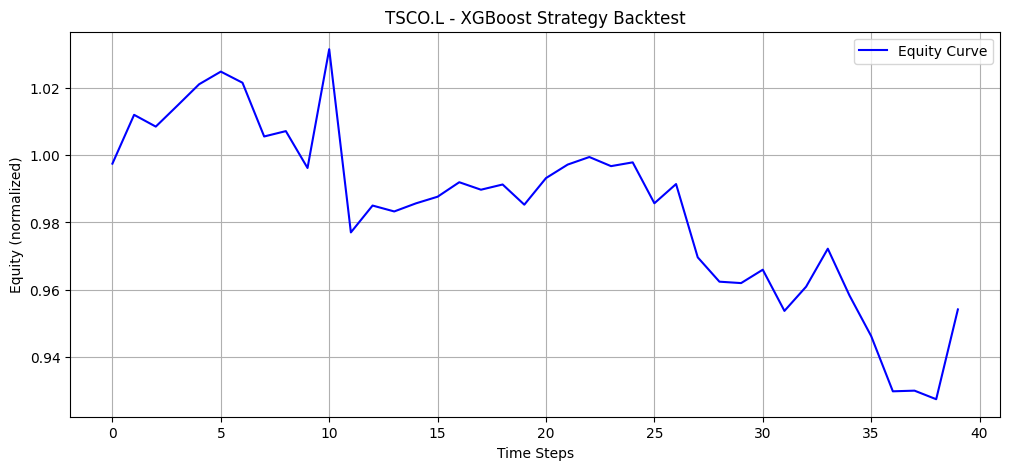


[NXT.L] Random Forest Strategy Performance:
Final Equity Value : 0.838
Sharpe Ratio       : -3.77
Max Drawdown       : -17.33%


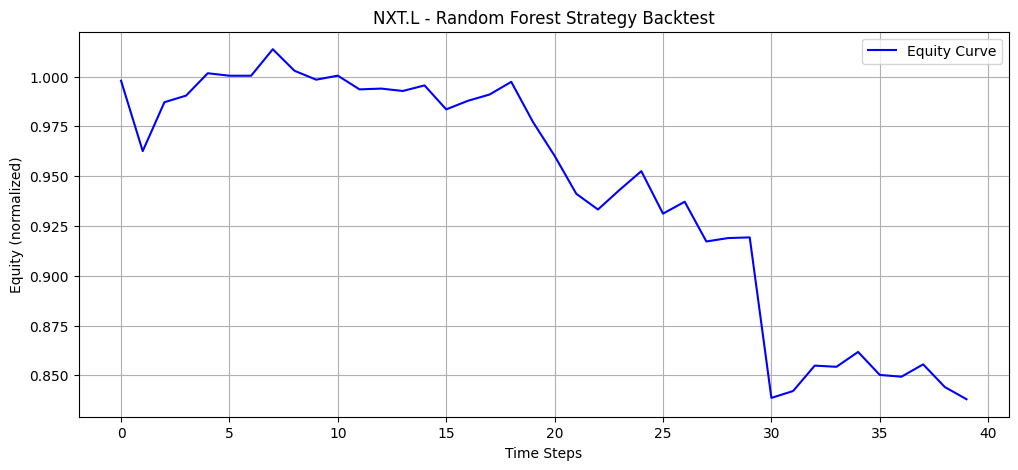


[NXT.L] Ridge Regression Strategy Performance:
Final Equity Value : 0.979
Sharpe Ratio       : -0.31
Max Drawdown       : -12.84%


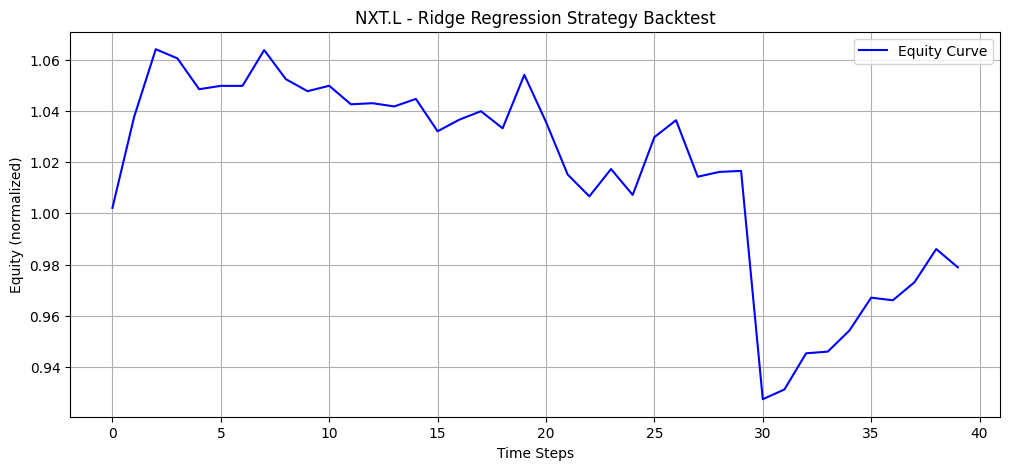


[NXT.L] XGBoost Strategy Performance:
Final Equity Value : 0.876
Sharpe Ratio       : -2.74
Max Drawdown       : -14.24%


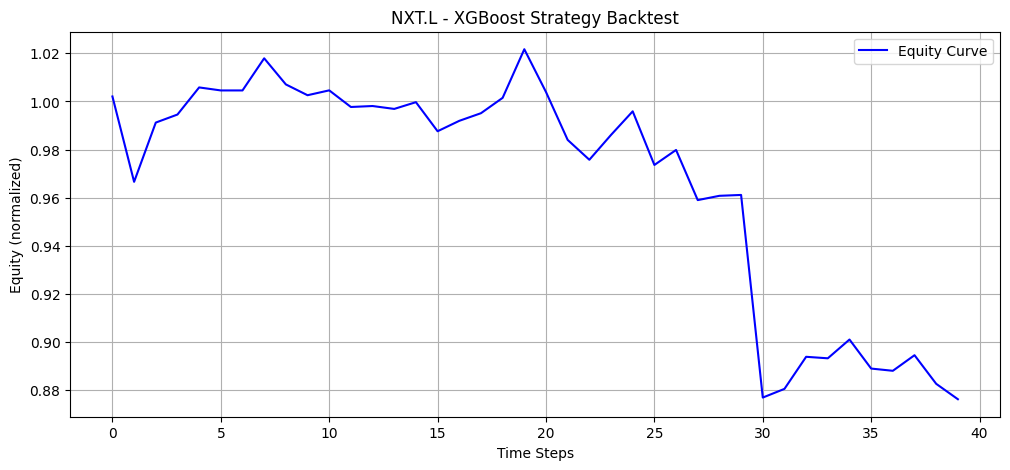

In [ ]:
models_list = ["Random Forest", "Ridge Regression", "XGBoost"]

for ticker in tickers:
    split_idx = split_idx_dict[ticker]
    df_for_current_prices = df_processed_for_target_dict[ticker]
    current_prices_for_signal = df_for_current_prices[ticker].values[split_idx:]
    y_actual_next_prices = y_test_dict[ticker]

    for model_name in models_list:
        y_predicted_next_prices = predictions_dict[ticker][model_name]
        min_len = min(len(current_prices_for_signal), len(y_actual_next_prices), len(y_predicted_next_prices))
        current_prices = current_prices_for_signal[:min_len]
        y_actual = y_actual_next_prices[:min_len]
        y_pred = y_predicted_next_prices[:min_len]

        backtest_strategy(current_prices, y_actual, y_pred, ticker_name=ticker, model_name=model_name)